In [ ]:
# ===================================================================
# [노트북 안내] 이 노트북과 JYG_model_compare.ipynb의 관계
# ===================================================================
#
# 이 노트북(JYG.ipynb)은 Opinosis 리뷰 텍스트 클러스터링의 "최종 파이프라인"임.
#   전처리 -> TF-IDF(LemNormalize) 벡터화 -> KMeans(n_clusters=5) 최종 클러스터링
#   -> 클러스터별 키워드/소속 파일 해석 -> PCA 시각화 -> n_clusters 2~5 비교
#
# 같은 폴더의 JYG_model_compare.ipynb는 이 노트북을 그대로 복사한 뒤,
# DBSCAN·GMM 모델을 추가로 적용해 KMeans 결과를 교차 검증한 "탐색적 비교" 노트북임.
#   (GMM은 KMeans와 결과가 완전히 동일했고, DBSCAN은 eps 파라미터에 따라
#    노이즈 판정이 민감하게 바뀜을 확인 - 자세한 내용/근거는 해당 노트북 하단
#    주석 셀 참고)
#
# 최종적으로 채택한 결과는 이 노트북의 KMeans(n_clusters=5) 클러스터링이며,
# JYG_model_compare.ipynb는 그 결과를 검증하기 위한 보조 자료임.

In [74]:
import pandas as pd
import glob, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

  
path = r'C:\big21\ml-dev\data\topics'
# path로 지정한 디렉터리 밑에 있는 모든 .data 파일들의 파일명을 리스트로 취합
all_files = glob.glob(os.path.join(path, "*.data"))    
filename_list = []
opinion_text = []


# 개별 파일들의 파일명은 filename_list 리스트로 취합,
# 개별 파일들의 파일 내용은 DataFrame 로딩 후 다시 string으로 변환하여 opinion_text 리스트로 취합
for file_ in all_files:
    # 개별 파일을 읽어서 DataFrame으로 생성
    df = pd.read_table(file_,index_col=None, header=0,encoding='latin1')
   
    # 절대경로로 주어진 file 명을 가공. 만일 Linux에서 수행시에는 아래 \\를 / 변경.
    # 맨 마지막 .data 확장자도 제거
    filename_ = file_.split('\\')[-1]
    filename = filename_.split('.')[0]


    # 파일명 리스트와 파일 내용 리스트에 파일명과 파일 내용을 추가.
    filename_list.append(filename)
    opinion_text.append(df.to_string())


# 파일명 리스트와 파일 내용 리스트를  DataFrame으로 생성
document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
document_df.head()

,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ..."
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ..."
3,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\n0 I love this ipod except for the battery life .\n1 ...
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n0 Not to mention that as of now..."


In [75]:
# 텍스트 전처리(정제, 토큰화, 불용어 제거)에 필요한 라이브러리 불러오기
import pandas as pd
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

In [76]:
def text_cleaning(text):
   
    # 소문자로 변환
    text = text.lower()
   
    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z\s]', ' ', text)
   
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
   
    return text.strip()

In [77]:
# 원문 보관 (혹시모를 상황을 대비)
document_df['original_text'] = document_df['opinion_text']

#소문자 / 영문자/공백/여러개공백 처리
document_df['opinion_text'] = document_df['opinion_text'].apply(text_cleaning)

# 토크나이즈(각 단어들로 구분)
document_df['opinion_text'] = document_df['opinion_text'].apply(word_tokenize)

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 불용어 정리
document_df['opinion_text'] = document_df['opinion_text'].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words and len(word) > 1
    ]
)

# 클렌징 및 토큰화 후, 최종 확인
document_df[['opinion_text']].head()

,opinion_text
0,"[accurate, part, find, garmin, software, provides, accurate, directions, whereever, intend, go, function, accurate, leave, battery, mode, say, stop, cracker, barrell, lunch, play, one, trangle, games, tees, provides, immediate, alternatives, route, online, map, program, inaccurate, blocked, obstacle, used, gps, units, well, gps, built, cars, day, nothing, beats, accuracy, garmin, gps, got, point, point, accuracy, everytime, yet, disappoint, getting, everywhere, accuracy, stars, honest, accurate, review, please, read, aside, every, destination, thrown, accurate, closing, fantastic, gps, nice, features, accurate, directions, plus, always, heard, quirks, gps, accurate, pois, etc, destinatio..."
1,"[room, overly, big, clean, comfortable, beds, great, shower, clean, bathrooms, second, room, smaller, inconvenient, bathroom, layout, least, quieter, able, sleep, large, comfortable, room, wonderful, bathroom, rooms, nice, comfy, bed, clean, bathroom, bathroom, spacious, clean, bathroom, single, sink, large, room, standard, nice, motel, room, like, bathroom, seemed, upgraded, remember, room, quite, small, perfectly, formed, super, bathroom, could, eat, bathroom, floor, clean, bathroom, door, thing, making, bathroom, seem, slightly, larger, bathroom, spotless, nicely, appointed, rooms, exceptionally, clean, also, bathrooms, bathroom, clean, bed, comfy, provide, great, aveda, products, bat..."
2,"[plugged, usb, hub, computer, charge, battery, charging, cord, design, clever, paged, tru, page, book, one, page, time, get, chapter, chapter, see, excited, low, battery, time, took, get, user, replaceable, battery, unless, buy, extended, warranty, year, pay, plus, shipping, send, device, amazon, kindle, replaced, battery, changed, fact, kindle, sd, card, capability, battery, user, serviceable, issue, things, like, buttons, made, easy, accidentally, turn, pages, separate, cursor, side, could, select, lines, sometimes, hard, see, occasionally, awkward, menus, case, practically, forced, remove, use, sometimes, pulled, battery, door, issue, battery, door, opening, thus, solved, amazon, went..."
3,"[short, battery, life, moved, gb, love, ipod, except, battery, life, long, battery, scratch, resistant, battery, drains, even, use, wonder, battery, seems, drain, using, even, sliding, top, control, button, shutting, great, car, light, portable, good, quality, long, battery, scratch, resistant, lies, mature, ipod, many, steps, wiser, able, one, year, old, ipod, gains, many, incremental, improvements, including, brighter, screen, better, video, battery, life, probably, appealing, aspect, tantalizing, price, points, gb, version, huge, gb, version, gb, better, battery, life, rated, battery, dummie, proof, love, color, ipod, battery, life, amazing, definitely, need, get, case, wanted, get, n..."
4,"[ghz, fsb, cpu, glossy, display, cell, wh, li, ion, battery, mention, asus, sell, spare, cell, li, ion, battery, also, features, cpu, cell, wh, li, ion, battery, mp, webcam, cell, wh, li, ion, battery, whopping, realistic, battery, numbers, battery, life, using, wifi, email, word, processing, youtube, web, surfing, eee, super, hybrid, engine, utility, lets, users, overclock, underclock, eee, pc, boost, performance, provide, better, battery, life, depending, immediate, requirements, things, like, point, must, push, micro, sized, right, angle, end, ac, adapter, snaps, place, battery, may, charge, addition, ac, adapter, get, quite, hot, actively, charging, battery, asus, clearly, mentions, ..."


In [78]:
#단어 빈도수 체크에 대한 함수

from collections import Counter
from nltk.tokenize import word_tokenize

for index, row in document_df.iterrows():
   
    # 클렌징된 텍스트 가져오기
    text = row['opinion_text']
   
    # 단어 빈도 계산
    word_counts = Counter(text)
   
    print(f"===== {row['filename']} =====")
    print(word_counts.most_common(30))
    print()

===== accuracy_garmin_nuvi_255W_gps =====
[('accurate', 48), ('accuracy', 13), ('gps', 12), ('directions', 11), ('easy', 9), ('map', 7), ('use', 7), ('used', 6), ('point', 6), ('time', 6), ('speed', 6), ('garmin', 5), ('destination', 5), ('always', 5), ('good', 5), ('unit', 5), ('turn', 5), ('one', 4), ('stars', 4), ('nice', 4), ('pretty', 4), ('arrival', 4), ('maps', 4), ('street', 4), ('tell', 4), ('roads', 4), ('find', 3), ('route', 3), ('inaccurate', 3), ('well', 3)]

===== bathroom_bestwestern_hotel_sfo =====
[('bathroom', 79), ('room', 36), ('clean', 23), ('bathrooms', 12), ('rooms', 12), ('nice', 12), ('small', 12), ('large', 10), ('sink', 10), ('also', 9), ('comfortable', 8), ('shower', 8), ('bed', 7), ('door', 7), ('good', 7), ('big', 6), ('well', 6), ('plenty', 6), ('quite', 5), ('little', 5), ('adequate', 5), ('enough', 5), ('hotel', 5), ('us', 5), ('space', 5), ('beds', 4), ('thing', 4), ('toilet', 4), ('basin', 4), ('one', 4)]

===== battery-life_amazon_kindle =====
[('bat

In [79]:
# 표제어 추출(lemmatization)을 위한 준비: 단/복수형, 활용형 단어를 원형으로 통일
import string
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

# 구두점을 지우기 위한 매핑 테이블 (문자 -> None)
remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()

# 토큰 리스트의 각 단어를 표제어(원형)로 변환
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

# 소문자화 + 구두점 제거 + 토큰화 + 표제어 추출을 한 번에 수행하는 함수
# TfidfVectorizer의 tokenizer 파라미터로 사용됨
def LemNormalize(text):
    text_new = text.lower().translate(remove_punct_dict)
    word_tokens = nltk.word_tokenize(text_new)
    return LemTokens(word_tokens)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mega\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mega\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [80]:
# 원문(original_text)을 LemNormalize로 전처리하며 TF-IDF 벡터로 변환
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,   # 토큰화 방식으로 위에서 만든 LemNormalize 사용
    stop_words='english',     # 영어 불용어 자동 제거
    ngram_range=(1, 2),       # 단어 1개(uni-gram)와 2개 묶음(bi-gram) 모두 특징으로 사용
    min_df=0.05,               # 전체 문서의 5% 미만에서만 등장하는 단어는 제외
    max_df=0.85                # 전체 문서의 85% 이상에서 등장하는(너무 흔한) 단어는 제외
)

feature_vect = tfidf_vect.fit_transform(document_df['original_text'])

In [81]:
# 최종 클러스터링: KMeans로 5개 그룹으로 분류
from sklearn.cluster import KMeans

km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)

# 문서별로 배정된 클러스터 번호를 컬럼으로 추가
document_df['cluster_label'] = km_cluster.labels_

# 같은 클러스터끼리 모아서 확인
document_df.sort_values(by='cluster_label')[['filename', 'cluster_label']]

,filename,cluster_label
5,buttons_amazon_kindle,0
10,eyesight-issues_amazon_kindle,0
12,fonts_amazon_kindle,0
23,navigation_amazon_kindle,0
27,price_amazon_kindle,0
28,price_holiday_inn_london,0
14,food_swissotel_chicago,1
1,bathroom_bestwestern_hotel_sfo,1
31,rooms_swissotel_chicago,1
21,location_holiday_inn_london,1


In [82]:
# 클러스터별 핵심 키워드와 소속 파일 확인 (군집의 의미 해석)
feature_names = tfidf_vect.get_feature_names_out()
cluster_centers = km_cluster.cluster_centers_

for cluster_num in range(km_cluster.n_clusters):
    print(f"===== Cluster {cluster_num} =====")

    # 중심(centroid)에서 TF-IDF 값이 높은 상위 10개 단어 = 이 군집을 대표하는 키워드
    top_idx = cluster_centers[cluster_num].argsort()[::-1][:10]
    top_terms = [feature_names[i] for i in top_idx]
    print("핵심 키워드:", top_terms)

    # 이 군집에 속한 문서(파일) 목록
    filenames = document_df[document_df['cluster_label'] == cluster_num]['filename'].values
    print("소속 파일:", list(filenames))
    print()

===== Cluster 0 =====
핵심 키워드: ['price', 'kindle', 'page', 'button', 'font', 'book', 'eye', 'navigation', 'font size', 'easy']
소속 파일: ['buttons_amazon_kindle', 'eyesight-issues_amazon_kindle', 'fonts_amazon_kindle', 'navigation_amazon_kindle', 'price_amazon_kindle', 'price_holiday_inn_london']

===== Cluster 1 =====
핵심 키워드: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'clean', 'bathroom', 'parking', 'room service']
소속 파일: ['bathroom_bestwestern_hotel_sfo', 'food_holiday_inn_london', 'food_swissotel_chicago', 'free_bestwestern_hotel_sfo', 'location_bestwestern_hotel_sfo', 'location_holiday_inn_london', 'parking_bestwestern_hotel_sfo', 'rooms_bestwestern_hotel_sfo', 'rooms_swissotel_chicago', 'room_holiday_inn_london', 'service_bestwestern_hotel_sfo', 'service_holiday_inn_london', 'service_swissotel_hotel_chicago', 'staff_bestwestern_hotel_sfo', 'staff_swissotel_chicago']

===== Cluster 2 =====
핵심 키워드: ['screen', 'keyboard', 'direction', 'map', 'voice', 'speed limit', 'accura

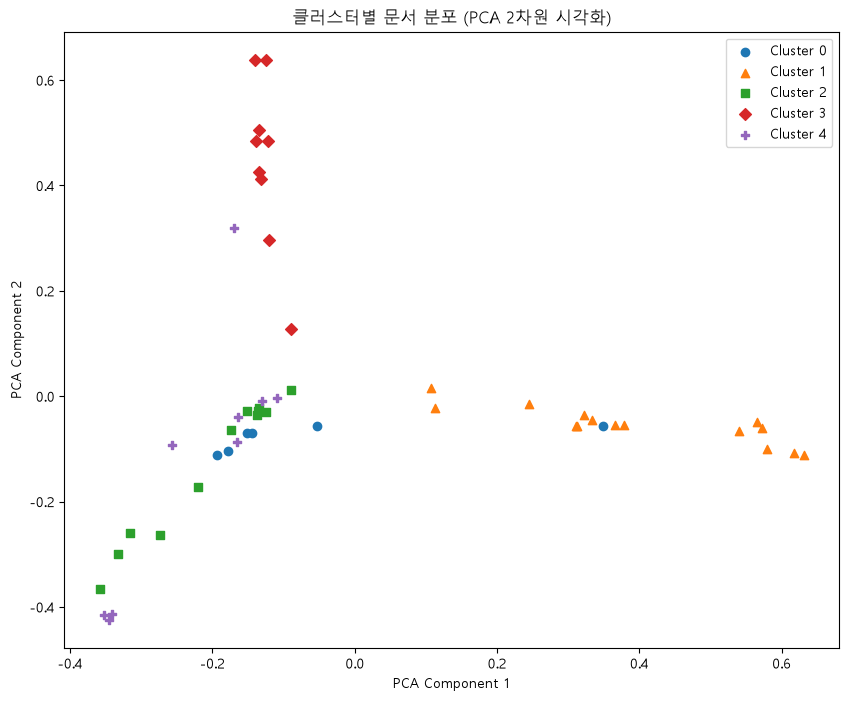

In [83]:
# PCA로 2차원 축소 후, 클러스터가 실제로 잘 나뉘었는지 시각화
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 그래프에 한글이 깨지지 않도록 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# PCA는 밀집 행렬(dense)만 입력받으므로, 희소 행렬인 feature_vect를 dense로 변환
pca = PCA(n_components=2, random_state=0)
pca_vect = pca.fit_transform(feature_vect.toarray())

# 시각화를 위해 축소된 2개 좌표값을 문서별로 저장
document_df['pca_x'] = pca_vect[:, 0]
document_df['pca_y'] = pca_vect[:, 1]

plt.figure(figsize=(10, 8))

markers = ['o', '^', 's', 'D', 'P']
for cluster_num in range(km_cluster.n_clusters):
    # 클러스터별로 점 모양을 다르게 해서 산점도에 표시
    cluster_data = document_df[document_df['cluster_label'] == cluster_num]
    plt.scatter(
        cluster_data['pca_x'], cluster_data['pca_y'],
        marker=markers[cluster_num % len(markers)],
        label=f'Cluster {cluster_num}'
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('클러스터별 문서 분포 (PCA 2차원 시각화)')
plt.legend()
plt.show()

In [84]:
# n_clusters를 2, 3, 4, 5로 바꿔가며 클러스터링 결과 비교
k_list = [2, 3, 4, 5]
km_results = {}  # k별 학습된 KMeans 모델을 저장해서 다음 셀(산점도)에서 재사용

for k in k_list:
    km = KMeans(n_clusters=k, max_iter=10000, random_state=0)
    km.fit(feature_vect)
    km_results[k] = km

    print(f"########## n_clusters={k} ##########")
    centers = km.cluster_centers_
    for cluster_num in range(k):
        # 클러스터 중심에서 TF-IDF 값이 높은 상위 10개 단어 = 핵심 키워드
        top_idx = centers[cluster_num].argsort()[::-1][:10]
        top_terms = [feature_names[i] for i in top_idx]
        # 이 클러스터에 속한 문서(파일) 목록
        filenames = document_df.loc[km.labels_ == cluster_num, 'filename'].values
        print(f"[Cluster {cluster_num}] 키워드: {top_terms}")
        print(f"           파일: {list(filenames)}")
    print()

########## n_clusters=2 ##########
[Cluster 0] 키워드: ['screen', 'battery', 'performance', 'keyboard', 'mileage', 'battery life', 'life', 'kindle', 'direction', 'video']
           파일: ['accuracy_garmin_nuvi_255W_gps', 'battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha', 'buttons_amazon_kindle', 'directions_garmin_nuvi_255W_gps', 'display_garmin_nuvi_255W_gps', 'eyesight-issues_amazon_kindle', 'features_windows7', 'fonts_amazon_kindle', 'gas_mileage_toyota_camry_2007', 'keyboard_netbook_1005ha', 'mileage_honda_accord_2008', 'navigation_amazon_kindle', 'performance_honda_accord_2008', 'performance_netbook_1005ha', 'price_amazon_kindle', 'quality_toyota_camry_2007', 'satellite_garmin_nuvi_255W_gps', 'screen_garmin_nuvi_255W_gps', 'screen_ipod_nano_8gb', 'screen_netbook_1005ha', 'size_asus_netbook_1005ha', 'sound_ipod_nano_8gb', 'speed_garmin_nuvi_255W_gps', 'speed_windows7', 'transmission_toyota_camry_2007', 'updates_garmin_nuvi_255W_gps', 'video_ipod_

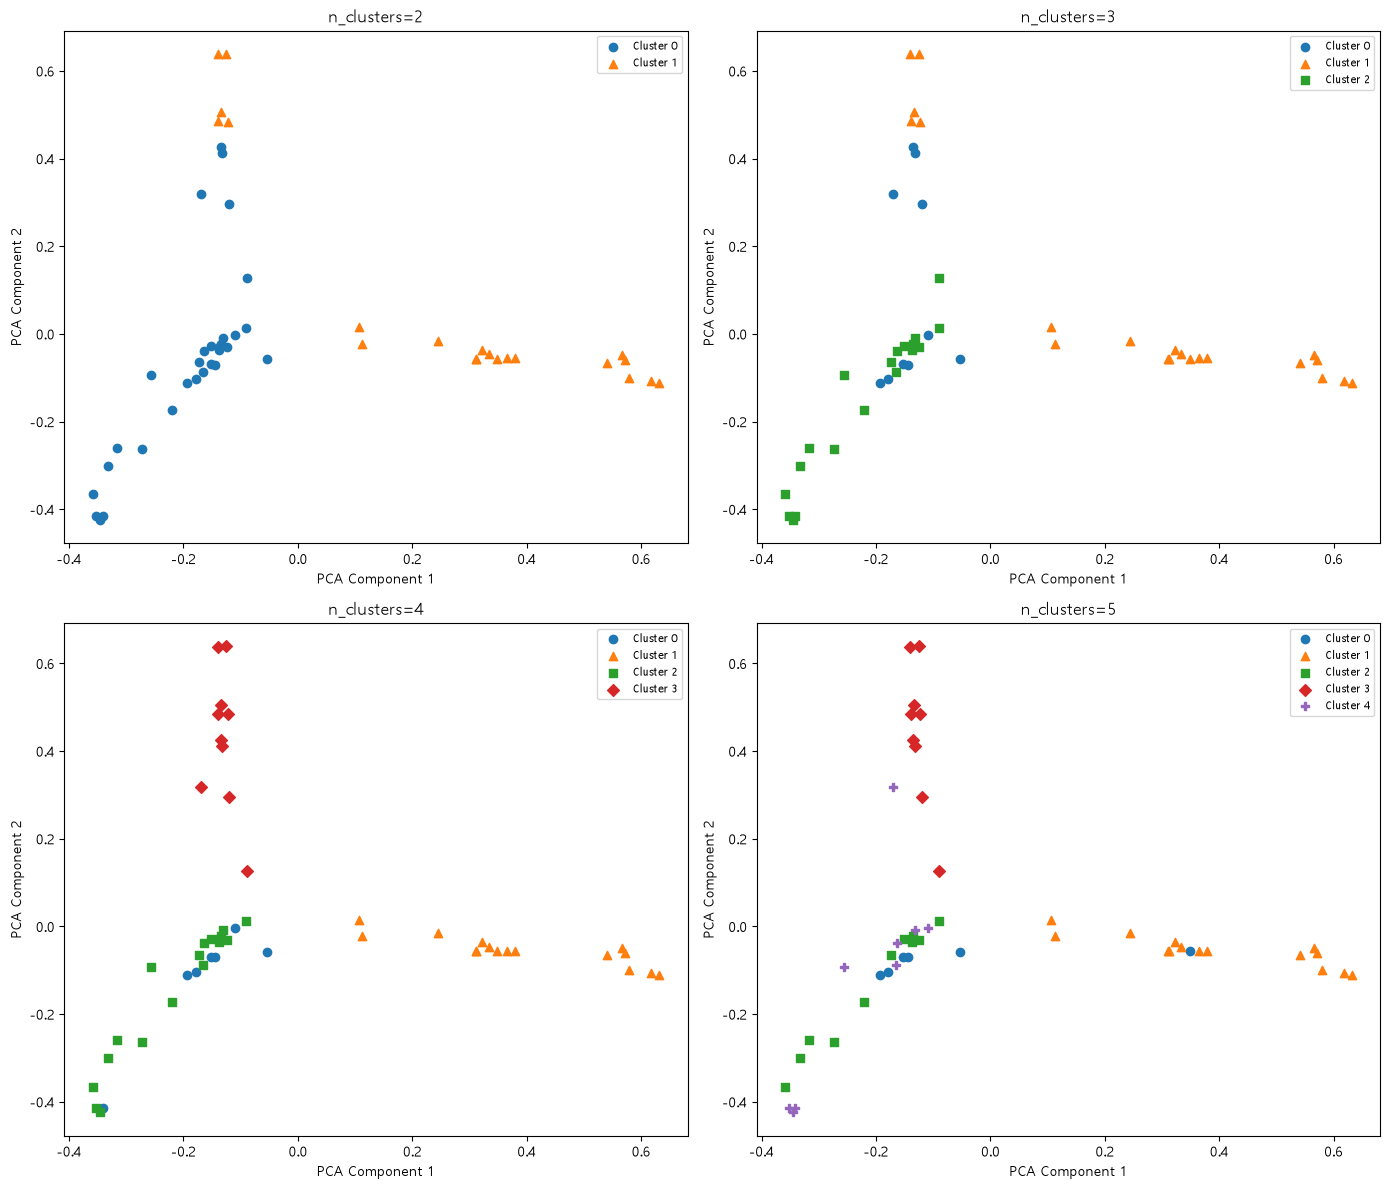

In [85]:
# n_clusters=2,3,4,5 각각의 PCA 2차원 산점도를 한눈에 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
markers = ['o', '^', 's', 'D', 'P']

for ax, k in zip(axes.flatten(), k_list):
    km = km_results[k]
    for cluster_num in range(k):
        # 같은 PCA 좌표(pca_vect)를 그대로 써서, k에 따라 군집 색만 다르게 표시
        mask = km.labels_ == cluster_num
        ax.scatter(
            pca_vect[mask, 0], pca_vect[mask, 1],
            marker=markers[cluster_num % len(markers)],
            label=f'Cluster {cluster_num}'
        )
    ax.set_title(f'n_clusters={k}')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()